## Analyse parameters and visualize statistics

Run this notebook after running StatisticsDataGeneration (sbl_benchmark_results.csv must exist).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the saved data
df = pd.read_csv("sbl_benchmark_results.csv")


### Success Rate Comparison Across Scenes and Configurations

Meaning: Comparing all iterations, how often we succeeded (%) for each scene based on each configuration combination.

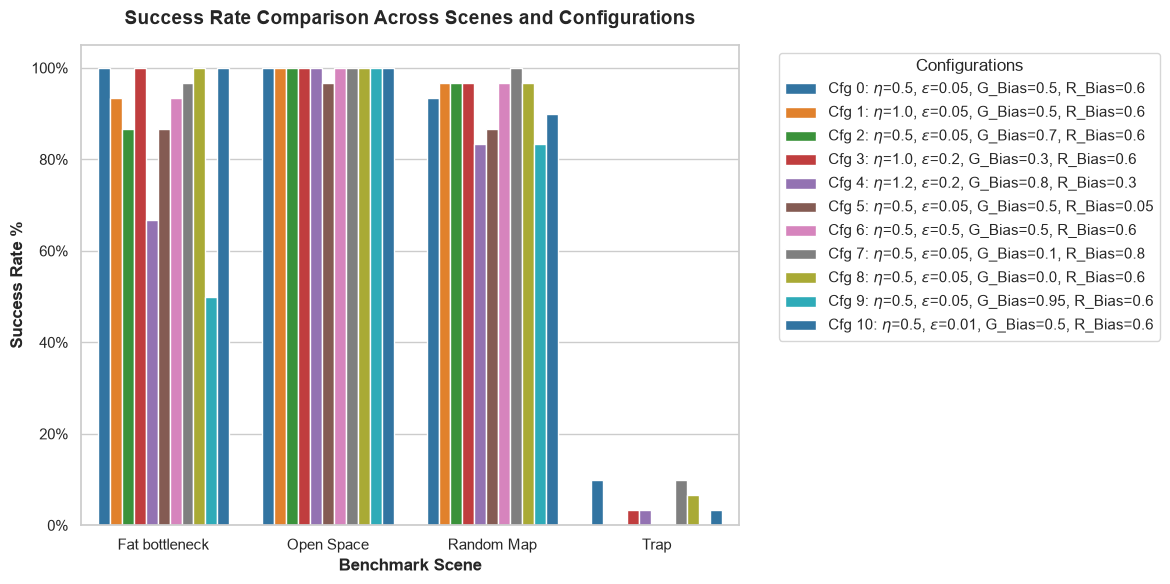

In [3]:
# 2. Calculate Success Rate
# Group by Scene and Config_Idx, then take the mean of 'Success' (True=1, False=0)
success_df = df.groupby(["Scene", "Config_Idx", "Eta", "Epsilon", "Goal_Bias", "Repair_Bias"])["Success"].mean().reset_index()

# 3. Create a readable label string for each config to use in the legend
success_df["Config_Label"] = success_df.apply(
    lambda row: rf"Cfg {int(row['Config_Idx'])}: $\eta$={row['Eta']}, $\epsilon$={row['Epsilon']}, G_Bias={row['Goal_Bias']}, R_Bias={row['Repair_Bias']}", 
    axis=1
)

# 4. Set up the plotting style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a bar plot using Seaborn
# x = Scene, y = Success Rate, hue = Config_Label
ax = sns.barplot(
    data=success_df, 
    x="Scene", 
    y="Success", 
    hue="Config_Label", 
    palette="tab10"
)

# 5. Graph formatting
plt.title("Success Rate Comparison Across Scenes and Configurations", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Benchmark Scene", fontsize=12, fontweight='bold')
plt.ylabel("Success Rate %", fontsize=12, fontweight='bold')
plt.ylim(0, 1.05) # Give a little room above 100% for the legend/labels

# Format y-axis as percentage
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Place the legend outside the plot area so it doesn't block the bars
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Configurations")

plt.tight_layout()
plt.show()

### Total Planning Time vs. Time to First Candidate

Meaning: If the total planning time is on the grey line (= time to 1st candidate), the 1st candidate was the successful path. The further away from the grey line, the more candidates we had until a path succeeded.

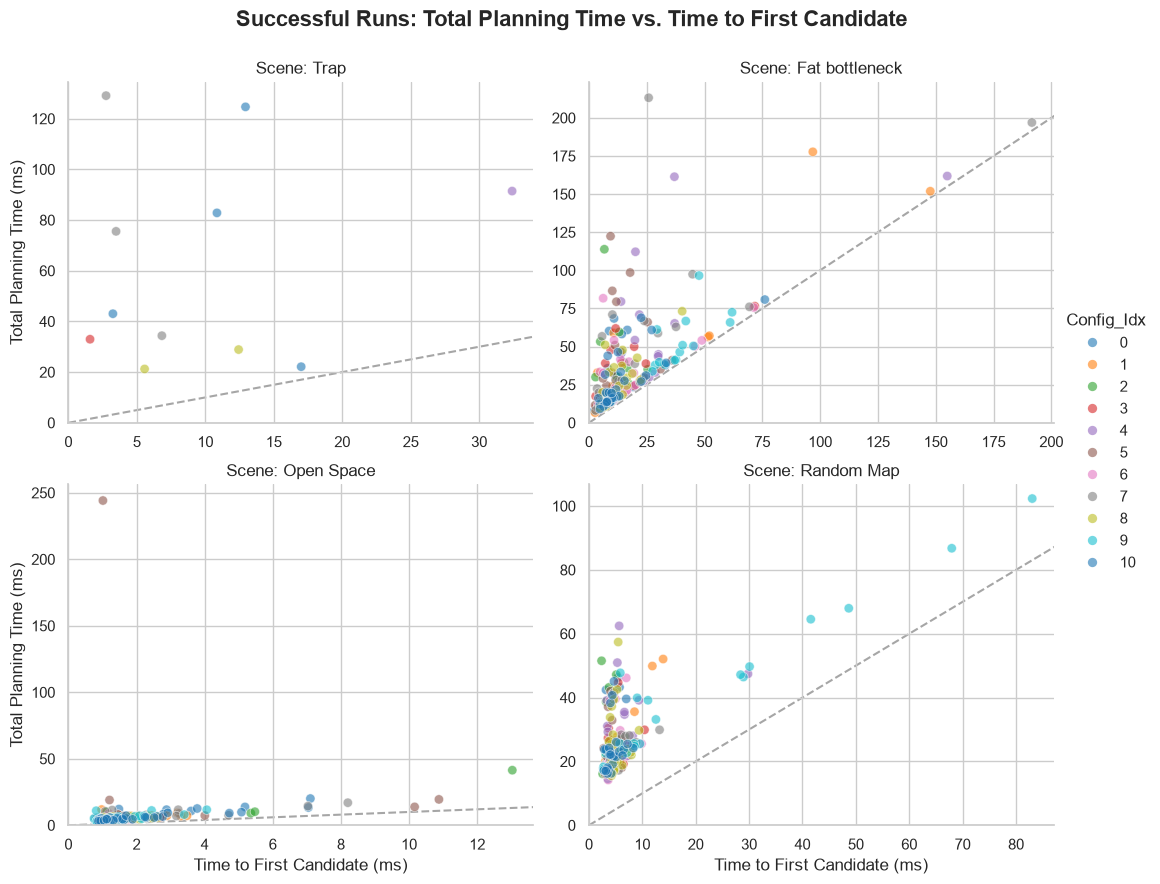

In [4]:
# Filter for successful runs
success_df = df[df["Success"] == True].copy()

# Convert timing columns from seconds to milliseconds (ms) for a cleaner "zoomed-in" scale
success_df["Time_First_Candidate_ms"] = success_df["Time_First_Candidate"] * 1000
success_df["Plan_Time_ms"] = success_df["Plan_Time"] * 1000

# 2. Set up the plotting theme
sns.set_theme(style="whitegrid")

# 3. Create a 2x2 faceted scatterplot with independent axis scales (sharex=False, sharey=False)
g = sns.relplot(
    data=success_df,
    x="Time_First_Candidate_ms",
    y="Plan_Time_ms",
    col="Scene",
    col_wrap=2,             
    hue="Config_Idx",     
    palette="tab10",
    alpha=0.6,              
    s=45,                   
    height=4.5,
    aspect=1.2,
    facet_kws={"sharex": False, "sharey": False}
    )

# 4. Add a diagonal reference line (y = x) to every individual subplot based on its own local limits
for ax in g.axes.flat:
    x_max = ax.get_xlim()[1]
    y_max = ax.get_ylim()[1]
    
    lims = [0, max(x_max, y_max) * 1.05]
    ax.plot(lims, lims, color='gray', linestyle='--', alpha=0.7, zorder=0, label='y = x')
    
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)

# 5. Format labels and titles
g.set_axis_labels("Time to First Candidate (ms)", "Total Planning Time (ms)")
g.set_titles(col_template="Scene: {col_name}")

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Successful Runs: Total Planning Time vs. Time to First Candidate", fontsize=16, fontweight='bold')

plt.show()

### Success Rate by Scene and Step Size ($\eta$)

Meaning: How often we succeeded per scene depending on the initial step size value. Small error bars (black) mean that eta had the most influence in the result, big bars mean other parameters had the most influence.

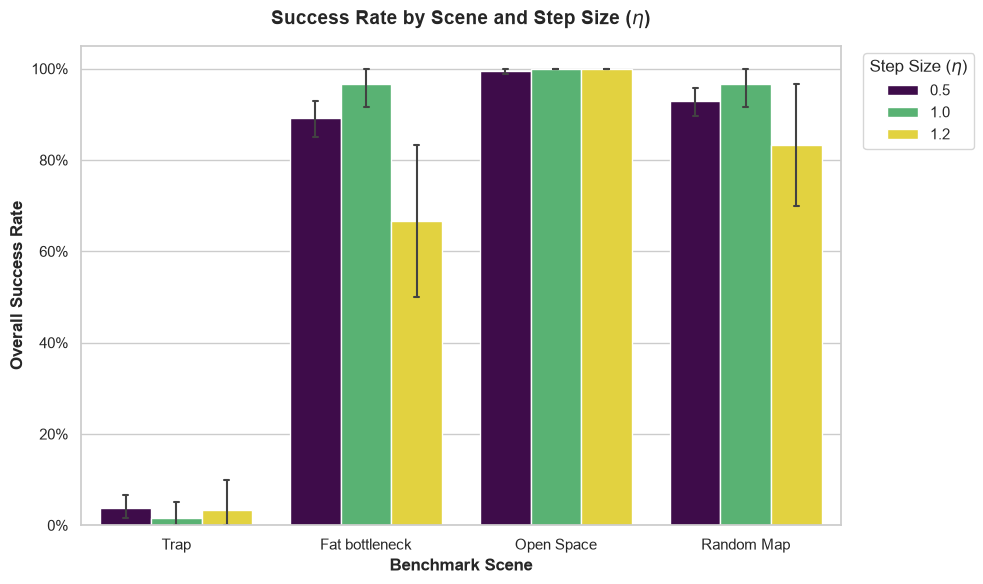

In [5]:
# 2. Convert 'Success' to float (1.0 or 0.0) for percentage calculation
df["Success_Num"] = df["Success"].astype(float)

# 3. Set up plot theme
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Plot Success Rate grouped by Scene and Eta
# Seaborn calculates mean success rate and adds error bars across all configs with the same Eta
ax = sns.barplot(
    data=df,
    x="Scene",
    y="Success_Num",
    hue="Eta",
    palette="viridis",
    capsize=0.08,    # Adds caps to error bars
    err_kws={'linewidth': 1.5}
)

# 5. Format labels and legend
plt.title(r"Success Rate by Scene and Step Size ($\eta$)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Benchmark Scene", fontsize=12, fontweight='bold')
plt.ylabel("Overall Success Rate", fontsize=12, fontweight='bold')
plt.ylim(0, 1.05)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Custom legend using raw string formatting to avoid syntax warnings
plt.legend(title=r"Step Size ($\eta$)", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Successful Runs: Total Planning Time by Scene and Adaptive Resolution ($\epsilon$)

Meaning: How the total planning time and the epsilon value relate for successful runs (path found). Small error bars mean epsilon had the most influence for the shown result, big bars mean other parameters influenced the results the most.

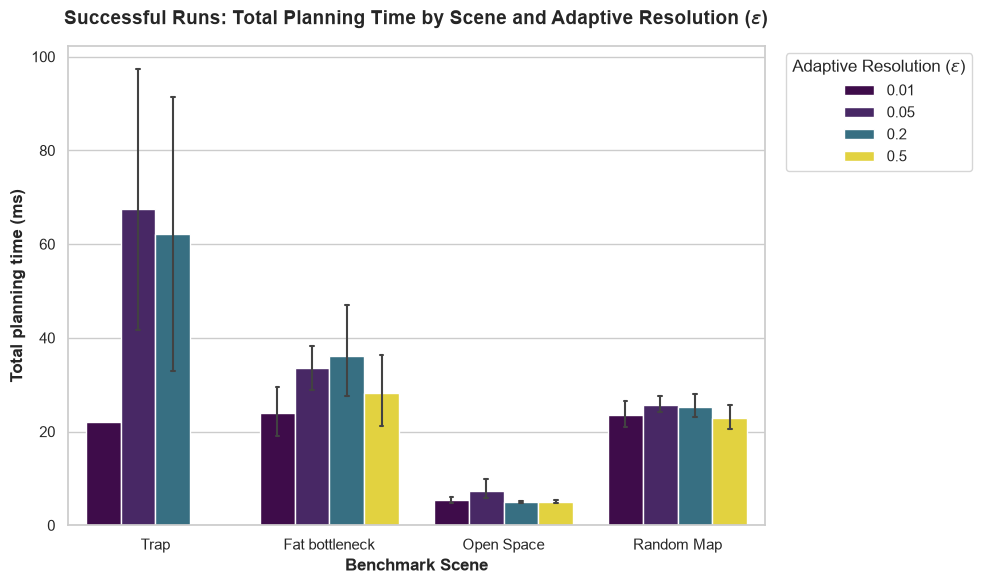

In [6]:
# Filter for successful runs
success_df = df[df["Success"] == True].copy()

# Convert to ms
success_df["Plan_Time_ms"] = success_df["Plan_Time"] * 1000

# 3. Set up plot theme
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Plot Planning Time grouped by Scene and Epsilon
# Seaborn calculates mean success rate and adds error bars across all configs with the same Eta
ax = sns.barplot(
    data=success_df,
    x="Scene",
    y="Plan_Time_ms",
    hue="Epsilon",
    palette="viridis",
    capsize=0.08,    # Adds caps to error bars
    err_kws={'linewidth': 1.5}
)

# 5. Format labels and legend
plt.title(r"Successful Runs: Total Planning Time by Scene and Adaptive Resolution ($\epsilon$)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Benchmark Scene", fontsize=12, fontweight='bold')
plt.ylabel("Total planning time (ms)", fontsize=12, fontweight='bold')


# Custom legend using raw string formatting to avoid syntax warnings
plt.legend(title=r"Adaptive Resolution ($\epsilon$)", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Tree Expansion Symmetry (Goal Tree / Start Tree Ratio)
Core Insight: SBL grows two trees simultaneously (from Start and Goal). In symmetric, open environments, both trees should grow at roughly the same rate. However, in asymmetric environments or when Goal_Bias or Repair_Bias are misconfigured, one tree dominates.

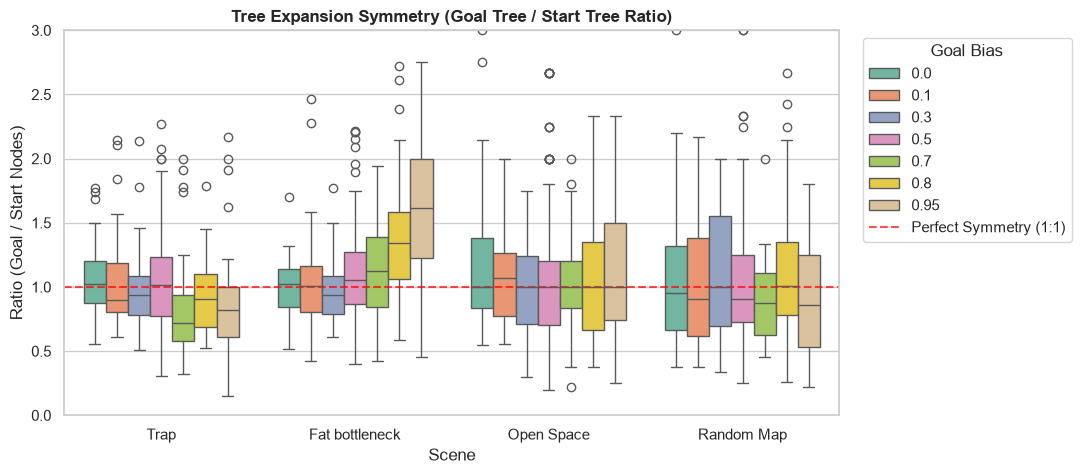

In [7]:
# Create tree balance metric
df["Tree_Imbalance"] = (df["Nodes_Goal_Tree"] - df["Nodes_Start_Tree"]).abs()
df["Tree_Ratio"] = df["Nodes_Goal_Tree"] / (df["Nodes_Start_Tree"] + 1e-5)

# Boxplot across Scenes
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Scene", y="Tree_Ratio", hue="Goal_Bias", palette="Set2")

plt.axhline(1.0, color='red', linestyle='--', alpha=0.7, label="Perfect Symmetry (1:1)")

# Cap the Y-axis to focus on the core distributions
plt.ylim(0, 3.0)  # Adjust upper limit based on where your non-outlier whiskers end

plt.title("Tree Expansion Symmetry (Goal Tree / Start Tree Ratio)", fontweight='bold')
plt.ylabel("Ratio (Goal / Start Nodes)")
plt.legend(title="Goal Bias", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### Edge Discovery Efficiency (Valid vs. Invalid Edges)

The Core Insight: SBL maintains lazy/deferred evaluation of edges. High numbers of Edges_Invalid mean the planner spent significant effort generating candidate connections through obstacle-filled regions that eventually failed validation. Unknown edges show how much work the lazy checking saved in comparison to checking edges directly after creation.

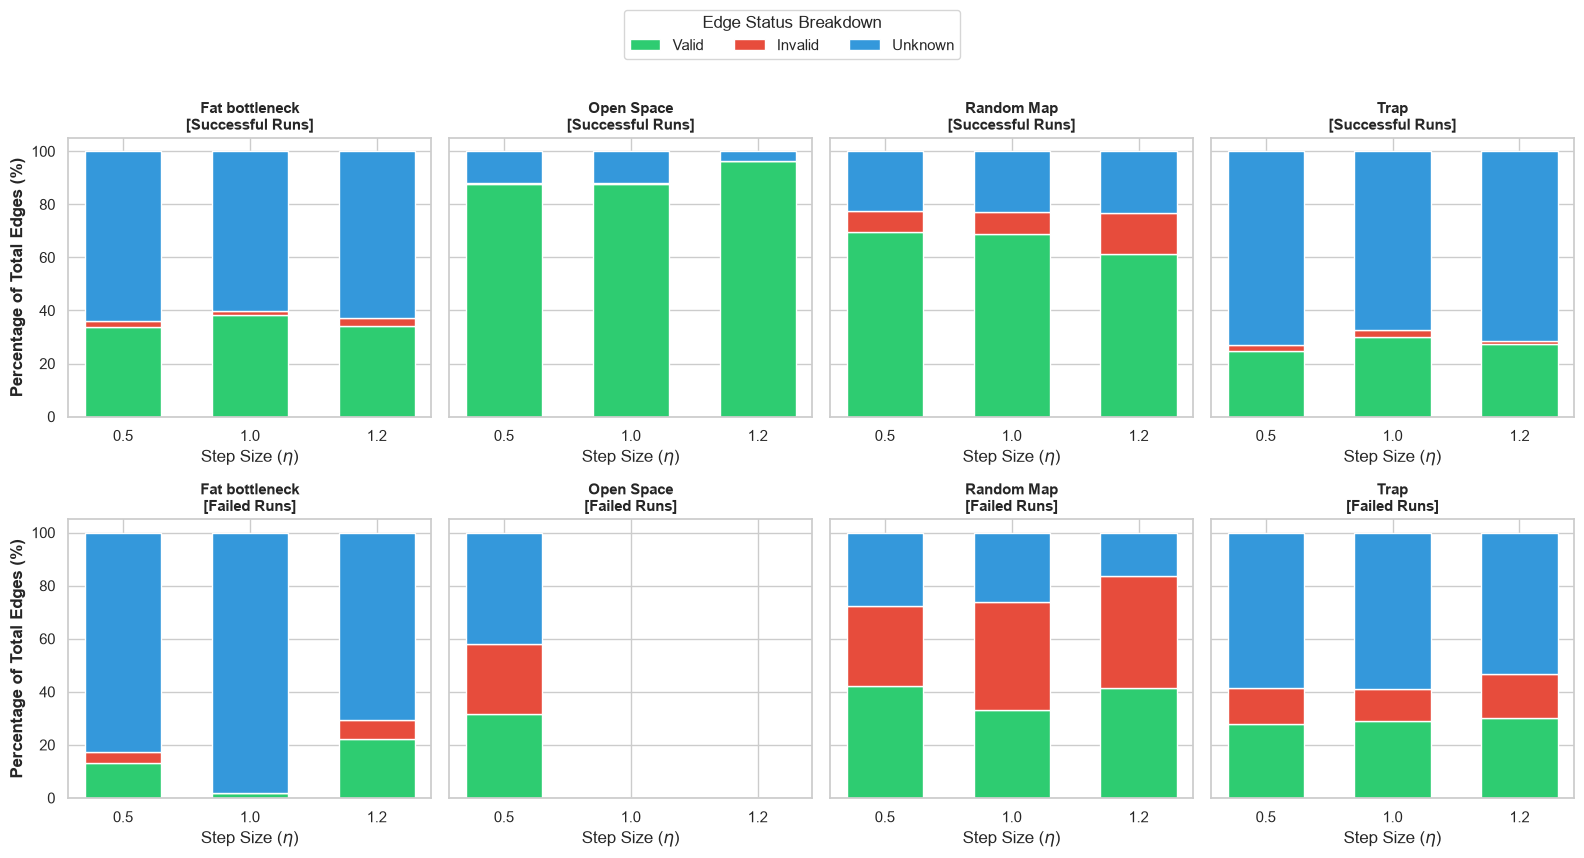

In [8]:
# 2. Calculate Total Edges generated per run
df["Total_Edges"] = df["Edges_Valid"] + df["Edges_Invalid"] + df["Edges_Unknown"]

# 3. Calculate proportions (normalize to 100%)
df["Pct_Valid"] = (df["Edges_Valid"] / df["Total_Edges"]) * 100
df["Pct_Invalid"] = (df["Edges_Invalid"] / df["Total_Edges"]) * 100
df["Pct_Unknown"] = (df["Edges_Unknown"] / df["Total_Edges"]) * 100

# Get all unique Eta values across the dataset to fix the x-axis alignment
all_etas = sorted(df["Eta"].unique())

# 4. Group by Scene, Success status, and Eta
edge_summary = (
    df.groupby(["Scene", "Success", "Eta"])[["Pct_Valid", "Pct_Invalid", "Pct_Unknown"]]
    .mean()
    .reset_index()
)

# Get unique scenes and setup a 2-row grid (Row 1: Successful, Row 2: Failed)
scenes = edge_summary["Scene"].unique()
fig, axes = plt.subplots(2, len(scenes), figsize=(4 * len(scenes), 8), sharey=True)

sns.set_theme(style="whitegrid")

# Color palette for edge states
color_valid = "#2ecc71"    # Green
color_invalid = "#e74c3c"  # Red
color_unknown = "#3498db"  # Blue

for col_idx, scene in enumerate(scenes):
    for row_idx, success_status in enumerate([True, False]):
        ax = axes[row_idx, col_idx] if len(scenes) > 1 else axes[row_idx]
        status_label = "Successful Runs" if success_status else "Failed Runs"
        
        # Filter data for specific scene and success status
        sub_data = edge_summary[
            (edge_summary["Scene"] == scene) & (edge_summary["Success"] == success_status)
        ]
        
        # If there are NO runs at all for this success condition in this scene
        if sub_data.empty:
            ax.text(0.5, 0.5, f"No {status_label}", ha='center', va='center', fontsize=11, color='gray')
            ax.set_title(f"{scene}\n[{status_label}]", fontweight='bold', fontsize=11)
            ax.set_xticks([])
            continue

        # Reindex sub_data so ALL eta values are represented (fills missing etas with NaN)
        full_grid = pd.DataFrame({"Eta": all_etas})
        merged_data = pd.merge(full_grid, sub_data, on="Eta", how="left").fillna(0)

        etas_str = [str(e) for e in merged_data["Eta"]]
        
        # Draw stacked bars with fixed categorical positions
        ax.bar(etas_str, merged_data["Pct_Valid"], label="Valid", color=color_valid, width=0.6)
        ax.bar(etas_str, merged_data["Pct_Invalid"], bottom=merged_data["Pct_Valid"], label="Invalid", color=color_invalid, width=0.6)
        ax.bar(etas_str, merged_data["Pct_Unknown"], bottom=merged_data["Pct_Valid"] + merged_data["Pct_Invalid"], label="Unknown", color=color_unknown, width=0.6)
        
        # Subplot Titles & Labels
        ax.set_title(f"{scene}\n[{status_label}]", fontweight='bold', fontsize=11)
        ax.set_xlabel(r"Step Size ($\eta$)")
        
        if col_idx == 0:
            ax.set_ylabel("Percentage of Total Edges (%)", fontweight='bold')

# Configure shared legend
handles, labels = axes[0, 0].get_legend_handles_labels() if len(scenes) > 1 else axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, title="Edge Status Breakdown", title_fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.91)
plt.show()

### SBL Lazy Evaluation Wasted Effort: First Candidate vs. First Valid Path
The Core Insight: In SBL, the time to propose the first candidate path (Time_First_Candidate) vs. the time to confirm a first valid path (Time_First_Valid) reveals how effective SBL's path-repair mechanism (Repair_Bias) actually is.
What to highlight in presentation: Show how much time SBL spends "repairing" invalid candidate paths versus generating new ones. An optimal Repair_Bias minimizes this gap.

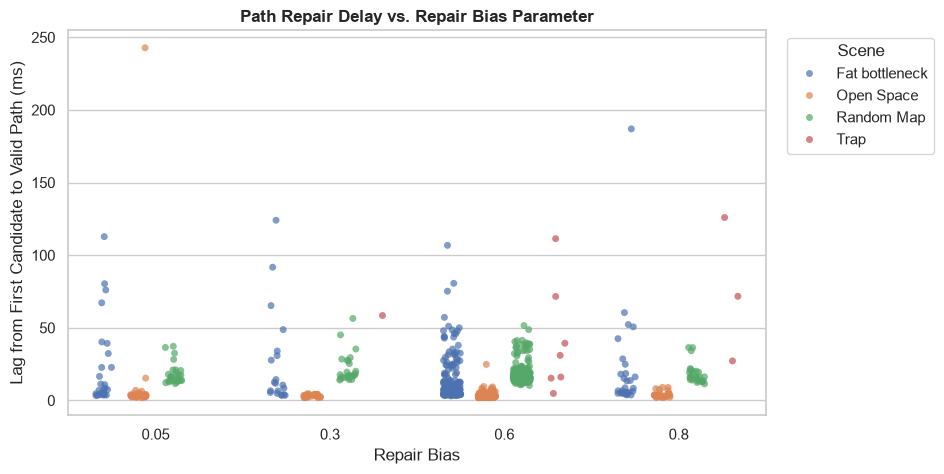

In [9]:
# Focus on successful runs where a valid path was found
success_df["Repair_Lag_ms"] = (success_df["Time_First_Valid"] - success_df["Time_First_Candidate"]) * 1000

plt.figure(figsize=(9, 5))
sns.stripplot(data=success_df, x="Repair_Bias", y="Repair_Lag_ms", hue="Scene", dodge=True, jitter=0.2, alpha=0.7)
plt.title("Path Repair Delay vs. Repair Bias Parameter", fontweight='bold')
plt.xlabel("Repair Bias")
plt.ylabel("Lag from First Candidate to Valid Path (ms)")

plt.legend(title="Scene", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### Configuration ranking by success rate

In [15]:
# import pandas as pd
# import numpy as np

# # 1. Load benchmark results
# df = pd.read_csv("sbl_benchmark_results.csv")

# Ensure required composite metrics exist
df["Time_ms"] = df["Plan_Time"] * 1000
df["Total_Edges"] = df["Edges_Valid"] + df["Edges_Invalid"] + df["Edges_Unknown"]
df["Edge_Efficiency"] = (df["Edges_Valid"] / (df["Edges_Valid"] + df["Edges_Invalid"] + 1e-5)) * 100
df["Collision_Checks"] = df["Point_Checks"] + df["Line_Checks"]

# 2. Group by Configuration (Config_Idx or Parameter combination)
# If you don't have Config_Idx, group by ["Eta", "Epsilon", "Goal_Bias", "Repair_Bias"]
config_group = df.groupby(["Config_Idx", "Eta", "Epsilon", "Goal_Bias", "Repair_Bias"])

# 3. Aggregate across metrics
summary_df = config_group.agg(
    Success_Rate=("Success", lambda x: (x.sum() / len(x)) * 100),
    Mean_Time_ms=("Time_ms", "mean"),
    Median_Time_ms=("Time_ms", "median"),
    Mean_Collision_Checks=("Collision_Checks", "mean"),
    Mean_Edge_Efficiency=("Edge_Efficiency", "mean"),
    Mean_Path_Length=("Final_Path_Length", lambda x: x[df.loc[x.index, "Success"]].mean() if any(df.loc[x.index, "Success"]) else np.nan)
).reset_index()

# 4. Format columns for publication/presentation
summary_df["Success Rate (%)"] = summary_df["Success_Rate"].map("{:.1f}%".format)
summary_df["Avg Time (ms)"] = summary_df["Mean_Time_ms"].map("{:.1f}".format)
summary_df["Med Time (ms)"] = summary_df["Median_Time_ms"].map("{:.1f}".format)
summary_df["Avg Checks"] = summary_df["Mean_Collision_Checks"].map("{:.0f}".format)
summary_df["Edge Efficiency (%)"] = summary_df["Mean_Edge_Efficiency"].map("{:.1f}%".format)
summary_df["Avg Path Length"] = summary_df["Mean_Path_Length"].map("{:.2f}".format)

# 5. Select & Rename key presentation columns
display_cols = [
    "Config_Idx", "Eta", "Epsilon", "Goal_Bias", "Repair_Bias",
    "Success Rate (%)", "Avg Time (ms)", "Med Time (ms)",
    "Avg Checks", "Edge Efficiency (%)", "Avg Path Length"
]

matrix_df = summary_df[display_cols].sort_values(by="Success Rate (%)", ascending=False)

# Output as Markdown for easy copy-pasting into slides/documents
print("### Multi-Metric Parameter Comparison Matrix\n")
print(matrix_df.to_markdown(index=False))

### Multi-Metric Parameter Comparison Matrix

|   Config_Idx |   Eta |   Epsilon |   Goal_Bias |   Repair_Bias | Success Rate (%)   |   Avg Time (ms) |   Med Time (ms) |   Avg Checks | Edge Efficiency (%)   |   Avg Path Length |
|-------------:|------:|----------:|------------:|--------------:|:-------------------|----------------:|----------------:|-------------:|:----------------------|------------------:|
|           10 |   0.5 |      0.01 |        0.5  |          0.6  | 73.3%              |            18.6 |            16.3 |          183 | 88.1%                 |             26.72 |
|            9 |   0.5 |      0.05 |        0.95 |          0.6  | 58.3%              |            39.3 |            33.4 |          849 | 70.8%                 |             24.54 |
|            8 |   0.5 |      0.05 |        0    |          0.6  | 75.8%              |            18.1 |            16.1 |          135 | 90.7%                 |             28.83 |
|            7 |   0.5 |      0.05 |   